# Python as a conversation
## Lesson 01 · ACTAM 2026

OK, so what is Python? What is a REPL? And what can we do with it?

For our purposes, we can imagine Python as someone we ask to do things. Our requests use a particular language: a precise language that the Python interpreter can execute. This is a useful metaphor, as long as we remember that Python follows rules rather than guessing what we mean.

We will begin with small expressions and work our way towards making a sound. Along the way, we will use names, lists, functions and a recipe for generating samples.

### How to use this notebook

Run the code cells from top to bottom with **Shift+Enter**. Pause at the questions, make a prediction, then try it. Markdown cells contain the discussion. Code cells contain instructions for Python.

A notebook remembers the names created by earlier cells. If a result seems strange, restart the kernel and run all cells in order. Editing a cell does not change anything until you run it again.

The examples use Matplotlib and IPython, available in the lesson's Jupyter environment. Audio appears as a player you can click, so running the notebook does not automatically play every sound. An optional section shows the original sounddevice approach.

## 1. A conversation with Python

We often imagine programming like this: we write all the instructions for a program, then ask the computer to execute them. Think of a video game. This is a simplification, of course, but it is a familiar picture.

There is also a more interactive way. We give Python a small instruction, look at the result, then decide what to ask next. It is a little like the difference between sending a long letter and having a conversation. The next thing we say can depend on the answer we just received.

That makes an interactive environment useful for exploring. We do not have to know every instruction in advance.

### What is a REPL?

REPL stands for **Read, Evaluate, Print, Loop**. Python reads an input, evaluates it, displays a result and waits for the next input.

A notebook gives us a related way of working, with saved cells, text, plots and other outputs. One cell can contain several instructions. Usually, the notebook automatically displays the value of the last expression in a code cell.

OK, what can we ask our interlocutor to do? One of the main things is to **evaluate an expression**. Let's start with a very small one.

In [1]:
1

1

Here, `1` is already an expression. Its value is the integer one. What other expressions do we have?

In [6]:
1 + 1

2

In [38]:
2 ** 3

8

`**` means exponentiation. Python integers can grow much larger than the fixed-size integers used in many other settings. Let's try it.

In [39]:
2 ** 1000

10715086071862673209484250490600018105614048117055336074437503883703510511249361224931983788156958581275946729175531468251871452856923140435984577574698574803934567774824230985421074605062371141877954182153046474983581941267398767559165543946077062914571196477686542167660429831652624386837205668069376

### Parentheses and order

Before running the next two cells, predict the results. Multiplication takes precedence over addition. Parentheses let us choose a different grouping.

In [40]:
(1 + 2) * 3

9

In [41]:
1 + 2 * 3

7

## 2. Giving values names

We can keep a value around by giving it a name. `=` is an assignment: evaluate the expression on the right, then bind the name on the left to its value.

An assignment is a statement, so it does not automatically display a result.

In [42]:
a = 1
b = 2

In [43]:
a + b

3

A name is not a permanent equation. If we change `a`, later expressions use its new value. Earlier outputs remain a record of what happened when we ran those cells.

In [44]:
a = a + 10
a + b

13

**Try it.** Run the previous cell again. Why does the result change? Reset `a` to `1` if you want to repeat the experiment from the beginning.

## 3. A collection of related values

Now imagine we want to represent a series of related measurements, such as the temperature of a room over time. We could give each measurement its own name.

In [45]:
t_0 = 20.0
t_1 = 21.5
t_2 = 20.3

If we want the third measurement, we can write `t_2`. But what if the position comes from a calculation?

Python does not turn a piece of a variable name into an expression. Something like `t_(1 + 1)` would mean a function call, not a request for the value named `t_2`.

We need a collection whose elements we can retrieve by position. Python gives us **lists**.

In [46]:
[1, 2, 3, 4]

[1, 2, 3, 4]

In [47]:
t = [20.1, 20.3, 20.5, 100.0]

### Positions start at zero

The first element has index `0`, the second has index `1`, and so on. For our four-element list, the valid non-negative indices are `0`, `1`, `2` and `3`.

The expression inside square brackets tells Python which element to retrieve.

In [48]:
t[0]

20.1

In [49]:
t[1 + 1]

20.5

The index can come from a calculation. `%` gives the remainder after division. Here it gives us a position within this list.

In [50]:
index = (2 ** 1234) % len(t)
t[index]

20.1

`len(t)` returns the number of elements. `t[4]` would raise an `IndexError`: there is no fifth element. An error message is useful feedback about our request.

**Try it.** Predict `t[-1]`. Negative indices count backwards from the end, so `-1` selects the last element.

### Calculating an average

We could add each measurement explicitly and divide by four.

In [51]:
(t[0] + t[1] + t[2] + t[3]) / 4

40.225

We can also ask Python to sum the whole list.

In [52]:
sum(t) / 4

40.225

This works, but the number `4` only makes sense while the list has four elements. Using its length expresses what we actually mean.

In [53]:
sum(t) / len(t)

40.225

The list must contain at least one value, otherwise we would divide by zero. Also, look at the value `100.0`: the calculation is correct, but that reading strongly affects the average. Does it describe the room, or might it be a measurement problem?

## 4. Functions and calls

`sum` and `len` are **functions**. A function is something we can call to perform an operation. A call can take arguments and can return a value.

The general shape is `function_name(argument_1, argument_2)`. Each argument can itself be an expression. Different functions expect different numbers and kinds of arguments.

In `sum(t) / len(t)`, Python calls two functions and divides their results. The whole thing is another expression.

In [54]:
print('Number of measurements:', len(t))
print('Average temperature:', sum(t) / len(t))

Number of measurements: 4
Average temperature: 40.225


`print` displays information explicitly. That is useful when we want several results from one cell. Its return value is `None`, which the notebook does not automatically show.

## 5. What does adding lists mean?

OK, what do you think it means to add two lists? Make a prediction before running this.

In [55]:
[1, 2, 3] + [10, 20, 30]

[1, 2, 3, 10, 20, 30]

For Python lists, `+` means **concatenation**: put the second list after the first. It does not add corresponding elements.

Given that, what might multiplying a list by an integer mean?

In [56]:
[1, 2, 3] * 2

[1, 2, 3, 1, 2, 3]

It repeats the sequence. We could have guessed that, but the meaning comes from Python's rules for lists.

We are using Python lists here. Numerical arrays, such as NumPy arrays, have different rules for these operators. We will keep that distinction in mind.

In [57]:
[0] * 10 + [1] * 10

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

**Try it.** Make a list containing five zeros, five ones and five zeros again. Then repeat the whole pattern three times. Where do the parentheses belong?

## 6. Shall we draw it?

A little new machinery: we import the plotting part of Matplotlib and give it the short name `plt`. An import makes code from a library available to us.

The `%matplotlib inline` line is an IPython instruction that asks for plots inside the notebook.

In [58]:
%matplotlib inline
from matplotlib import pyplot as plt

In [59]:
plt.plot

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data: 'DataParamType' = None, **kwargs) -> 'list[Line2D]'>

### What does the dot mean?

We have already called functions such as `sum(t)`. Now we encounter `plt.plot(...)`. What is that dot doing?

The dot asks Python to look up a name on an object. That named value is called an **attribute**. Here, `plt` refers to the plotting module we imported, and `plot` is a function available in that module.

In the previous cell, `plt.plot` retrieves the function without calling it. Adding parentheses, as in `plt.plot([0, 1, 0])`, calls that function and passes it an argument. The parentheses do the same job as before.

### An operation on a particular list

The same dot syntax also lets us find a **method**: an operation associated with a particular object. Let's ask a list to append one more value.

In [60]:
notes = [440, 550]
notes.append(660)
notes

[440, 550, 660]

`append` is a method of the list. Calling it changes `notes` itself by adding a value at the end. It returns `None`, so we inspect `notes` on the next line to see the changed list.

The distinction to keep is small but useful: the **dot looks up an attribute**, and the **parentheses call it** if it is callable. `plt.plot` is a function provided by a module; `notes.append` is a method of a list. Other attributes can simply hold data and cannot be called.

OK, let's use that syntax to draw our pattern.

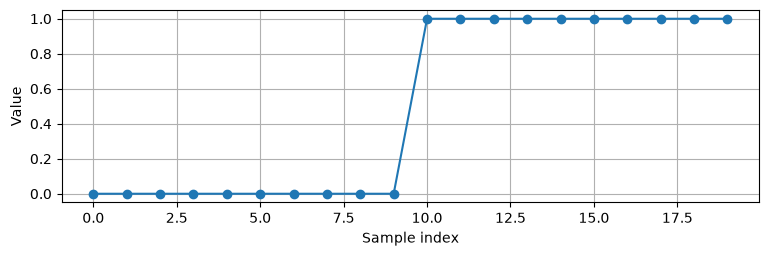

In [61]:
step = [0] * 10 + [1] * 10
plt.figure(figsize=(9, 2.5))
plt.plot(step, marker='o')
plt.xlabel('Sample index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

We supplied only the vertical values. Matplotlib used the positions `0, 1, 2, ...` for the horizontal axis. The lines join the samples to help us see the pattern.

What happens if we repeat that pattern?

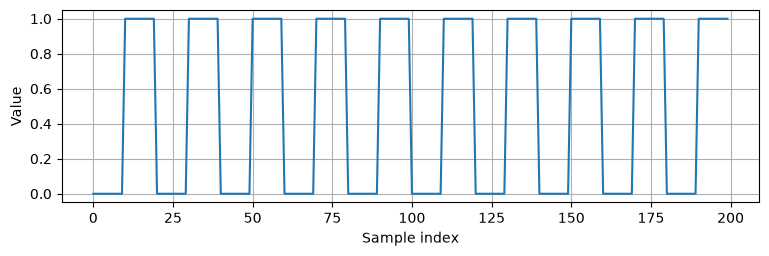

In [62]:
plt.figure(figsize=(9, 2.5))
plt.plot(step * 10)
plt.xlabel('Sample index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

## 7. Could this list be a sound?

OK, what else could we do with this list? We could interpret its numbers as a sequence of **samples** describing a waveform.

To turn samples into sound, we also need a **sample rate**: how many samples to play each second. We will use 48,000 samples per second throughout the lesson.

These examples use floating-point values and a small amplitude. Start with a low listening volume.

In [63]:
from IPython.display import Audio, display

SR = 48_000
amplitude = 0.15

Our earlier pattern moved between zero and one. For sound, let's use a square wave centred around zero: ten negative samples followed by ten positive samples.

The period has 20 samples. Repeating it 2,400 times gives 48,000 samples, or one second of sound.

In [64]:
square_period = [-amplitude] * 10 + [amplitude] * 10
square = square_period * 2400
Audio(square, rate=SR, normalize=False)

Click the player to listen. `normalize=False` keeps the amplitude we chose. Otherwise the audio widget would rescale the signal.

**Try it.** Make each half of the period 20 samples long instead of 10. What happens to the pitch? What happens if you only change the number of repetitions?

A longer period lowers the frequency at a fixed sample rate. More repetitions extend the sound without changing its frequency.

### Optional: playing directly with sounddevice

The original experiment used `sounddevice`. You can run the following code in a new cell to send the samples directly to the computer's audio output:

```python
import sounddevice as sd
sd.play(square, samplerate=SR)
sd.wait()
```

`sd.wait()` waits until playback finishes. Use `sd.stop()` to stop playback early. This requires an available output device that supports the requested sample rate. The embedded players above are convenient when Python runs on another machine.

A plain list of integers can become an unsupported `int64` array in sounddevice. This does **not** mean that sounddevice rejects every integer format: it supports specific integer formats as well as floating-point data. Using floats here keeps the examples straightforward. Python floats approximate real numbers with finite precision.

## 8. A siren with two frequencies

Can we alternate two pitches? We already have the tools: repetition makes each note longer, and concatenation puts one note after another.

Let's use periods of 120 and 80 samples. The next section will explain why those give 400 Hz and 600 Hz at our sample rate.

In [65]:
low_period = [-amplitude] * 60 + [amplitude] * 60
high_period = [-amplitude] * 40 + [amplitude] * 40
low_note = low_period * 200
high_note = high_period * 300
siren = (low_note + high_note) * 3
Audio(siren, rate=SR, normalize=False)

Each note contains 24,000 samples, so each lasts half a second. The complete siren lasts three seconds.

**Try it first.** Change the alternation speed while keeping the pitches. Then change the pitches while keeping each note's duration close to half a second.

## 9. Another shape: a rising ramp

Do we like that timbre? What other waveforms could we try?

Let's write a sequence that rises in small steps.

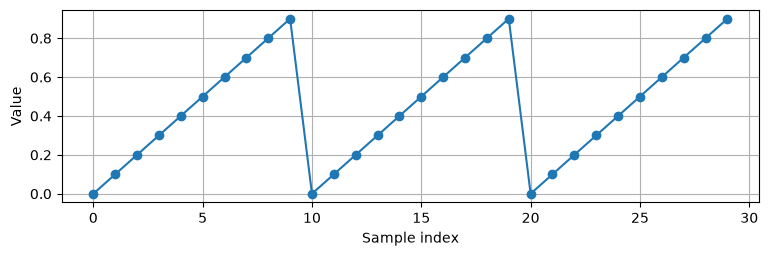

In [66]:
ramp_period = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
plt.figure(figsize=(9, 2.5))
plt.plot(ramp_period * 3, marker='o')
plt.xlabel('Sample index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Notice what happens at the boundary: the sequence jumps back down and starts rising again. This is a **sawtooth** waveform. A triangle would have a descending slope as well as an ascending one.

This short period would make a high sound. Could we make it longer? The boring way is to write more values.

In [67]:
longer_ramp_period = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30,
                      0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65,
                      0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
len(longer_ramp_period)

20

Can we go lower still? Ideally, we want to move from a literal list of samples to a **recipe** for calculating them.

## 10. A recipe for samples

`range(n)` produces the integers from `0` up to, but excluding, `n`. Let's inspect a small example.

In [68]:
list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

A **list comprehension** applies an expression to each value in a sequence:

```python
[expression for variable in sequence]
```

Read `[x / n for x in range(n)]` as: for each `x` in `range(n)`, calculate `x / n`, and collect the results into a list.

In [69]:
n = 20
ramp_period = [x / n for x in range(n)]
ramp_period

[0.0,
 0.05,
 0.1,
 0.15,
 0.2,
 0.25,
 0.3,
 0.35,
 0.4,
 0.45,
 0.5,
 0.55,
 0.6,
 0.65,
 0.7,
 0.75,
 0.8,
 0.85,
 0.9,
 0.95]

The final value is `(n - 1) / n`, just below one. We can now change one number to make a much longer period.

In [70]:
n = 1000
ramp_period = [x / n for x in range(n)]
len(ramp_period)

1000

For listening, we map the ramp into values around zero and scale it by our amplitude. The expression `2 * x / n - 1` starts at `-1` and approaches `+1`.

In [71]:
n = 300
saw_period = [amplitude * (2 * x / n - 1) for x in range(n)]
saw = saw_period * 160
Audio(saw, rate=SR, normalize=False)

We could also write the recipe directly inside the audio call. Naming the period makes it easier to inspect and reuse.

In [72]:
Audio([amplitude * (2 * x / 300 - 1) for x in range(300)] * 160,
      rate=SR, normalize=False)

## 11. What frequency are we hearing?

We need to relate samples to time. If the sample rate is $SR$ samples per second and a period contains $n$ samples, its duration is

$$T = \frac{n}{SR} \quad \text{seconds}.$$

Frequency counts periods per second, so

$$f = \frac{1}{T} = \frac{SR}{n} \quad \text{Hz}.$$

For $n = 300$ and $SR = 48{,}000$, what do we get?

In [73]:
n = 300
SR / n

160.0

That gives 160 Hz. The duration of the **whole sound** is a separate calculation: divide its total number of samples by the sample rate.

In [74]:
len(saw) / SR

1.0

### What if we want 440 Hz?

Rearranging the equation gives $n = SR / f$. Let's calculate the period length for A4.

In [75]:
SR / 440

109.0909090909091

A literal list cannot have a fractional number of samples. If we repeat a fixed list, we must choose an integer period length. Let's use the nearest integer and check the actual frequency.

In [76]:
target_frequency = 440
n = round(SR / target_frequency)
actual_frequency = SR / n
print('Samples per period:', n)
print('Actual frequency:', actual_frequency)
print('Difference in Hz:', actual_frequency - target_frequency)

Samples per period: 109
Actual frequency: 440.3669724770642
Difference in Hz: 0.3669724770642233


The result is about 440.37 Hz, slightly above 440 Hz. This is a limitation of repeating a fixed integer-length period. Later, a phase-based oscillator can represent frequencies without restricting every period boundary to an integer sample.

In [78]:
a4_period = [amplitude * (2 * x / n - 1) for x in range(n)]
a4 = a4_period * round(SR / n)
Audio(a4, rate=SR, normalize=False)

**Check your understanding.** At a fixed sample rate, what happens to frequency if we double `n`? What happens to both pitch and duration if we play the same sample list at half the sample rate?

## 12. A real triangle wave

Let's return to the triangle idea. We need a slope going up and a slope going down. We can build the two halves separately, then concatenate them.

We use 150 samples for each half, so the complete period has 300 samples, just like our 160 Hz sawtooth.

In [79]:
half_n = 150
up = [-amplitude + 2 * amplitude * x / half_n for x in range(half_n)]
down = [amplitude - 2 * amplitude * x / half_n for x in range(half_n)]
triangle_period = up + down
triangle = triangle_period * 160

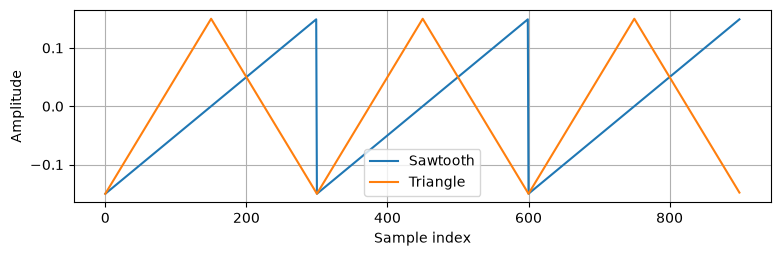

In [80]:
plt.figure(figsize=(9, 2.5))
plt.plot(saw_period * 3, label='Sawtooth')
plt.plot(triangle_period * 3, label='Triangle')
plt.xlabel('Sample index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

In [81]:
display(Audio(saw, rate=SR, normalize=False))
display(Audio(triangle, rate=SR, normalize=False))

Listen to the sawtooth first, then the triangle. They have the same period length, duration and peak amplitude. Does the triangle sound softer? The waveform shape changes the balance of harmonics, which contributes to timbre. Equal peak amplitudes do not guarantee equal perceived loudness.

These direct recipes are useful first experiments. Sharp transitions introduce high harmonics, some of which can exceed half the sample rate and alias into the audible band. More careful oscillator design is a topic for a later lesson.

## 13. Exercise: an A major arpeggio

Can you play an A major arpeggio in root position, starting at A4?

The notes are **A4, C♯5, E5**, with **A5** as an optional octave ending. In twelve-tone equal temperament, moving up $s$ semitones multiplies frequency by $2^{s/12}$. Relative to A4, the offsets are `0`, `4`, `7` and `12`.

Try building it before looking at the worked example below:

1. Calculate the target frequencies from 440 Hz.
2. Turn each frequency into an integer period length.
3. Generate a ramp period for each note.
4. Repeat each period to make roughly half a second of sound.
5. Concatenate the notes and listen.

Use the same sample rate and amplitude for all notes.

### Worked example: the pitches

First, let's keep the target frequencies and inspect how rounding the period lengths changes them.

In [82]:
offsets = [0, 4, 7, 12]
frequencies = [440 * 2 ** (s / 12) for s in offsets]
period_lengths = [round(SR / f) for f in frequencies]
realized_frequencies = [SR / n for n in period_lengths]
print('Target frequencies:', frequencies)
print('Samples per period:', period_lengths)
print('Actual frequencies:', realized_frequencies)

Target frequencies: [440.0, 554.3652619537442, 659.2551138257398, 880.0]
Samples per period: [109, 87, 73, 55]
Actual frequencies: [440.3669724770642, 551.7241379310345, 657.5342465753424, 872.7272727272727]


### Worked example: the notes

We can write each note explicitly using the tools we already know. The number of repetitions is approximately `duration * SR / n`, rounded to an integer.

In [84]:
duration = 0.5
n_a, n_cs, n_e, n_octave = period_lengths

note_a = [amplitude * (2 * x / n_a - 1) for x in range(n_a)] * round(duration * SR / n_a)
note_cs = [amplitude * (2 * x / n_cs - 1) for x in range(n_cs)] * round(duration * SR / n_cs)
note_e = [amplitude * (2 * x / n_e - 1) for x in range(n_e)] * round(duration * SR / n_e)
note_octave = [amplitude * (2 * x / n_octave - 1) for x in range(n_octave)] * round(duration * SR / n_octave)

arpeggio = note_a + note_cs + note_e + note_octave
Audio(arpeggio * 3, rate=SR, normalize=False)

`n_a, n_cs, n_e, n_octave = period_lengths` unpacks four values into four names. Rounding the repeat counts makes the note durations close to half a second, rather than exactly half a second.

**Try it.** Make the arpeggio descend. Then change it to A minor: which semitone offset needs to change? You may hear clicks at note boundaries because the samples change abruptly. Short amplitude fades are a useful next step.

## 14. What can we now ask Python to do?

We started with `1`. Now we can describe a sequence of samples with a recipe, draw it and listen to it.

The same small set of ideas keeps coming back: expressions calculate values, names let us reuse them, lists collect related values, and function calls ask for operations. A list comprehension gives us a compact recipe for an entire sequence.

Keep the conversation going: make a prediction, run a small experiment and use the result to decide what to try next.

### Exercise notes

- Five zeros, five ones and five zeros, repeated three times: `([0] * 5 + [1] * 5 + [0] * 5) * 3`.
- Doubling a period length halves its frequency at a fixed sample rate.
- Halving the playback sample rate halves frequency and doubles duration for the same samples.
- To alternate the siren faster, reduce each note's repetition count.
- A minor uses offsets `[0, 3, 7, 12]`.

### Further reference

- [Python tutorial: numbers and lists](https://docs.python.org/3/tutorial/introduction.html)
- [Python tutorial: list comprehensions](https://docs.python.org/3/tutorial/datastructures.html#list-comprehensions)
- [IPython Audio](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.Audio)
- [sounddevice playback and supported formats](https://python-sounddevice.readthedocs.io/en/latest/api/convenience-functions.html#sounddevice.play)